In [ ]:
from google.colab import drive
import matplotlib.pyplot as plt
drive.mount("/content/drive")
repo = "/content/drive/MyDrive/cs4782-final-project"
%cd {repo}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1sEpnQZ0N_zNDz-lLP5-y8B9O1R28rUfJ/cs4782-final-project


In [ ]:
!pip install -q -r requirements.txt

In [ ]:
# Use this if ur getting errors with pillow version
# !pip uninstall -y pillow
# !pip install --no-cache-dir pillow==11.3.0

In [ ]:
# import sys, pathlib
# sys.path.insert(0, str(pathlib.Path("../code").resolve()))
# sys.path.insert(0, str(pathlib.Path("..").resolve()))

import torch
from data.datasets import get_loader

from src.model import build_unet
from src.degradation import Degradation
from src.evaluate import evaluate_model
from src.train import train

device= "cuda" if torch.cuda.is_available() else "cpu"

print("device: ", device)

device:  cuda


In [ ]:
#def train (dataset_name, num_steps= 100_000, lr= 2e-5, batch_size= 32, grad_accum_steps= 2, ema_decay= 0.995, ema_update_every= 10, log_every= 500, save_every= 5000, ckpt_dir= "../checkpoints", resume= False, device= None):
losses = train("mnist",
      num_steps= 100000,
      lr= 2e-5,
      batch_size= 32,
      grad_accum_steps= 2,
      ema_decay= 0.995,
      ema_update_every= 10,
      log_every= 500,
      save_every= 5000,
      ckpt_dir= "./checkpoints",
      degradation_type="party",
      resume= False,
      device= device)

[train] dataset= mnist device= cuda
 [train] step=     500 loss= 0.0894
 [train] step=    1000 loss= 0.0772
 [train] step=    1500 loss= 0.0745
 [train] step=    2000 loss= 0.0738
 [train] step=    2500 loss= 0.0733
 [train] step=    3000 loss= 0.0730
 [train] step=    3500 loss= 0.0723
 [train] step=    4000 loss= 0.0718
 [train] step=    4500 loss= 0.0716
 [train] step=    5000 loss= 0.0712
[train] saved ckpt at step 5000
 [train] step=    5500 loss= 0.0717
 [train] step=    6000 loss= 0.0711
 [train] step=    6500 loss= 0.0713
 [train] step=    7000 loss= 0.0713
 [train] step=    7500 loss= 0.0704
 [train] step=    8000 loss= 0.0703
 [train] step=    8500 loss= 0.0706
 [train] step=    9000 loss= 0.0709
 [train] step=    9500 loss= 0.0706
 [train] step=   10000 loss= 0.0706
[train] saved ckpt at step 10000
 [train] step=   10500 loss= 0.0706
 [train] step=   11000 loss= 0.0700
 [train] step=   11500 loss= 0.0707
 [train] step=   12000 loss= 0.0709
 [train] step=   12500 loss= 0.0698

Step: 500, Loss: 0.0894
Step: 1000, Loss: 0.0772
Step: 1500, Loss: 0.0745
Step: 2000, Loss: 0.0738
Step: 2500, Loss: 0.0733
Step: 3000, Loss: 0.0730
Step: 3500, Loss: 0.0723
Step: 4000, Loss: 0.0718
Step: 4500, Loss: 0.0716
Step: 5000, Loss: 0.0712
Step: 5500, Loss: 0.0717
Step: 6000, Loss: 0.0711
Step: 6500, Loss: 0.0713
Step: 7000, Loss: 0.0713
Step: 7500, Loss: 0.0704
Step: 8000, Loss: 0.0703
Step: 8500, Loss: 0.0706
Step: 9000, Loss: 0.0709
Step: 9500, Loss: 0.0706
Step: 10000, Loss: 0.0706
Step: 10500, Loss: 0.0706
Step: 11000, Loss: 0.0700
Step: 11500, Loss: 0.0707
Step: 12000, Loss: 0.0709
Step: 12500, Loss: 0.0698
Step: 13000, Loss: 0.0706
Step: 13500, Loss: 0.0702
Step: 14000, Loss: 0.0694
Step: 14500, Loss: 0.0695
Step: 15000, Loss: 0.0694
Step: 15500, Loss: 0.0700
Step: 16000, Loss: 0.0693
Step: 16500, Loss: 0.0699
Step: 17000, Loss: 0.0699
Step: 17500, Loss: 0.0695
Step: 18000, Loss: 0.0697
Step: 18500, Loss: 0.0691
Step: 19000, Loss: 0.0699
Step: 19500, Loss: 0.0701
Step: 

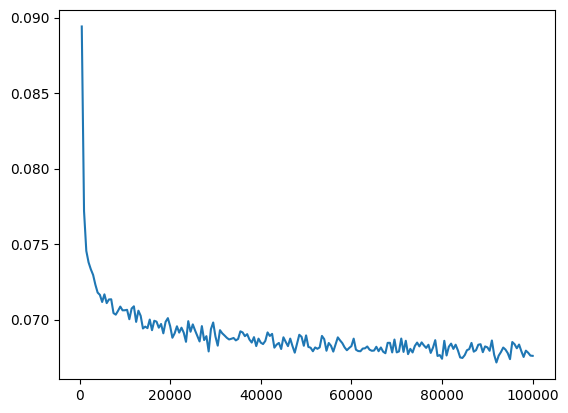

In [ ]:
for step, loss in losses:
    print(f"Step: {step}, Loss: {loss:.4f}")

plt.plot([step for step, loss in losses], [loss for step, loss in losses])